#Multi-Agent System — ArXiv Research Crew

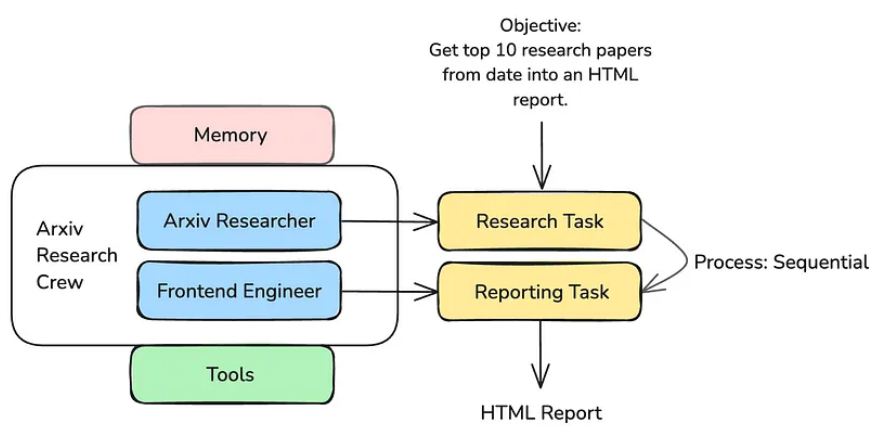

In [9]:
from typing import Type, List
from pydantic import BaseModel, Field
from crewai.tools import BaseTool

import arxiv
import time
import datetime
import os
from google.colab import userdata

from crewai import Agent
from crewai import Task
from crewai import Crew
#!pip install crewai crewai_tools arxiv

In [2]:
# Set up environment variables
openai_api_key = userdata.get('openai_api')

os.environ["OPENAI_API_KEY"] = openai_api_key
os.environ["OPENAI_MODEL_NAME"] = "gpt-4o-mini"

In [3]:
#ArXiv Search Tool
# Importing crewAI tools
from crewai_tools import (
    DirectoryReadTool,
    FileReadTool,
    SerperDevTool,
    WebsiteSearchTool
)

# Set up API keys for Serper
os.environ["SERPER_API_KEY"] = userdata.get('serper_api')

# Instantiate tools
docs_tool = DirectoryReadTool(directory='./your-directory') # Tool for reading documents from a specified directory
file_tool = FileReadTool() # Tool for reading individual files
search_tool = SerperDevTool() # Tool for performing web searches using the Serper API
web_rag_tool = WebsiteSearchTool() # Tool for searching and extracting information from websites

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_config.py:295: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  warnings.warn(DEPRECATION_MESSAGE, DeprecationWarning)
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_fields.py:192: UserWarning: Field name "schema" in "DatabricksQueryToolSchema" shadows an attribute in parent "BaseModel"
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:502: UserWarning: <built-in function callable> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
/usr/local/lib/python3.11/dist-packages/crewai_t

In [6]:

class FetchArxivPapersInput(BaseModel):
    """Input schema for FetchArxivPapersTool."""
    target_date: datetime.date = Field(..., description="Target date to fetch papers for.")

class FetchArxivPapersTool(BaseTool):
    name: str = "fetch_arxiv_papers"
    description: str = "Fetches all ArXiv papers from selected categories submitted on the target date."
    args_schema: Type[BaseModel] = FetchArxivPapersInput

    def _run(self, target_date: datetime.date) -> List[dict]:
        # List of AI-related categories.
        # You can also include ["cs.AI", "cs.LG", "cs.CV", "cs.MA", "cs.RO"]
        AI_CATEGORIES = ["cs.CL"]

        # Define the date range for the target date
        start_date = target_date.strftime('%Y%m%d%H%M')
        end_date = (target_date + datetime.timedelta(days=1)).strftime('%Y%m%d%H%M')

        # Initialize the ArXiv client
        client = arxiv.Client(
            page_size=100,  # Fetch 100 results per page
            delay_seconds=3  # Delay between requests to respect rate limits
        )

        all_papers = []

        for category in AI_CATEGORIES:
            print(f"Fetching papers for category: {category}")

            search_query = f"cat:{category} AND submittedDate:[{start_date} TO {end_date}]"

            search = arxiv.Search(
                query=search_query,
                sort_by=arxiv.SortCriterion.SubmittedDate,
                max_results=None  # Fetch all results
            )

            # Collect results for the category
            category_papers = []
            for result in client.results(search):
                category_papers.append({
                    'title': result.title,
                    'authors': [author.name for author in result.authors],
                    'summary': result.summary,
                    'published': result.published,
                    'url': result.entry_id
                })

                # Delay between requests to respect rate limits
                time.sleep(3)

            print(f"Fetched {len(category_papers)} papers from {category}")
            all_papers.extend(category_papers)

        return all_papers

In [7]:
arxiv_search_tool = FetchArxivPapersTool()

In [10]:
#ArXiv Researcher
researcher = Agent(
    role = "Senior Researcher",
    goal = "Find the top 10 papers from the search results from ArXiv on {date}."
            "Rank them appropirately.",
    backstory = "You are a senior researcher with a deep understanding of all topics in AI and AI research."
                "You are able to identify the best research papers based on the title and abstract.",
    verbose = True,
    tools = [arxiv_search_tool],
)

In [11]:
#Frontend Engineer
frontend_engineer = Agent(
    role = "Senior Frontend & AI Engineer",
    goal = "Compile the results into a HTML file.",
    backstory = "You are a competent frontend engineer writing HTML and CSS with decades of experience."
                "You have also been working with AI for decades and understand it well.",
    verbose = True,
)

In [12]:
#Tasks
research_task = Task(
    description = (" Find the top 10 research papers from the search results from ArXiv on {date}."),
    expected_output = (
        "A list of top 10 research papers with the following information in the following format:"
        "- Title"
        "- Authors"
        "- Abstract"
        "- Link to the paper"
    ),
    agent = researcher,
    human_input = True,
)

reporting_task = Task(
    description = ("Compile the results into a detailed report in a HTML file."),
    expected_output = (
        "An HTML file with the results in the following format:"
        "Top 10 AI Research Papers published on {date}"
        "- Title (which on clicking opens the paper in a new tab)"
        "- Authors"
        "- Short summary of the abstract (2-4 sentences)"
    ),
    agent = frontend_engineer,
    context = [research_task],
    output_file = "./ai_research_report.html",
    human_input = True,
)

In [13]:
#Create crew

arxiv_research_crew = Crew(
    agents = [researcher, frontend_engineer],
    tasks = [research_task, reporting_task],
    verbose = True,
)

In [ ]:
crew_inputs = {
    "date" : "2025-03-12"
}

result = arxiv_research_crew.kickoff(inputs = crew_inputs)